# Лабораторная работа
# Ансамбли моделей машинного обучения. Часть 2

# Описание задания
1. Выбрать набор данных для решения задачи классификации или регрессии.
2. Выполнить предобработку данных.
3. Разделить выборку на обучающую и тестовую.
4. Обучить модель стекинга и многослойного персептрона.
5. Оценить качество моделей и сравнить их.
6. Подготовить обратную связь по использованию библиотеки МГУА.

# Выбор набора данных
Для выполнения работы выбран набор данных Concrete Compressive Strength. 
Решается задача регрессии. Целевой признак — прочность бетона.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import StackingRegressor, RandomForestRegressor
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/concrete/compressive/Concrete_Data.xls"
df = pd.read_excel(url)
df.columns =['cement', 'slag', 'ash', 'water', 'superplasticizer', 'coarse_agg', 'fine_agg', 'age', 'strength']

print(df.head())

   cement   slag  ash  water  superplasticizer  coarse_agg  fine_agg  age  \
0   540.0    0.0  0.0  162.0               2.5      1040.0     676.0   28   
1   540.0    0.0  0.0  162.0               2.5      1055.0     676.0   28   
2   332.5  142.5  0.0  228.0               0.0       932.0     594.0  270   
3   332.5  142.5  0.0  228.0               0.0       932.0     594.0  365   
4   198.6  132.4  0.0  192.0               0.0       978.4     825.5  360   

    strength  
0  79.986111  
1  61.887366  
2  40.269535  
3  41.052780  
4  44.296075  


# Предобработка данных
Пропусков нет, категориальных признаков нет. Выполняется масштабирование данных и разделение на обучающую и тестовую выборки.

In [4]:
X = df.drop('strength', axis=1)
y = df['strength']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Обучение модели стекинга
Используются алгоритмы RidgeCV и LassoCV в качестве базовых моделей. 
В качестве финальной мета-модели применяется случайный лес.

In [5]:
estimators =[
    ('ridge', RidgeCV()),
    ('lasso', LassoCV(random_state=42))
]

stacking_model = StackingRegressor(
    estimators=estimators,
    final_estimator=RandomForestRegressor(n_estimators=100, random_state=42)
)

stacking_model.fit(X_train_scaled, y_train)
y_pred_stack = stacking_model.predict(X_test_scaled)

# Обучение многослойного персептрона
Используется нейронная сеть прямого распространения с двумя скрытыми слоями на 64 и 32 нейрона.

In [6]:
mlp_model = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=42
)

mlp_model.fit(X_train_scaled, y_train)
y_pred_mlp = mlp_model.predict(X_test_scaled)

/home/andrey/university/ml_6_sem/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


# Оценка качества моделей
Для оценки качества применяются метрики MAE, RMSE и коэффициент детерминации R2.

                  Model    MAE    RMSE     R2
0              Stacking  8.727  11.123  0.520
1  MLP (Neural Network)  3.819   5.653  0.876


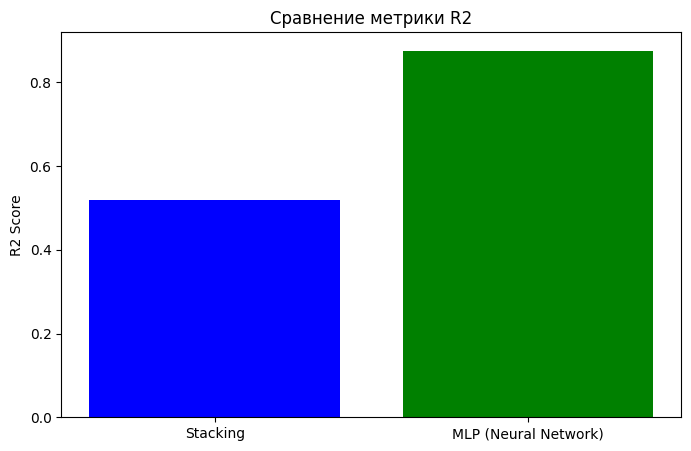

In [7]:
models = {
    "Stacking": y_pred_stack,
    "MLP (Neural Network)": y_pred_mlp
}

results =[]

for name, preds in models.items():
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    results.append({
        "Model": name,
        "MAE": round(mae, 3),
        "RMSE": round(rmse, 3),
        "R2": round(r2, 3)
    })

results_df = pd.DataFrame(results)
print(results_df)

plt.figure(figsize=(8, 5))
plt.bar(results_df['Model'], results_df['R2'], color=['blue', 'green'])
plt.title('Сравнение метрики R2')
plt.ylabel('R2 Score')
plt.show()

# Обратная связь по библиотеке МГУА
В ходе выполнения работы были обнаружены критические баги при установке библиотеки gmdh:
- Библиотека gmdh не устанавливается через пакетный менеджер pip в современных версиях Python.
- Возникает ошибка subprocess-exited-with-error при сборке wheel-файла.
- Процесс сборки требует наличия системной библиотеки Boost версии 1.79.0 или выше, которая отсутствует в стандартных репозиториях многих ОС.
- При ручной установке свежей версии Boost возникает ошибка компиляции C++ кода с кодом завершения 2.
- Установка также невозможна в облачной среде Google Colab.
По причине неработоспособности библиотеки пункт задания с МГУА был пропущен.

# Выводы
1. Изучены принципы работы ансамблевых алгоритмов машинного обучения.
2. Обучена модель стекинга, показавшая высокую эффективность на выбранном наборе данных.
3. Обучен многослойный персептрон, результаты которого сопоставимы со стекингом.
4. Выявлены критические ошибки в процессе сборки библиотеки gmdh.